# Week 4 Assignment: CIFAR-10 Image Classification
## Implementation and Comparison of ANN, CNN, and Advanced CNN Architectures

### Dataset Details
The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes:
*Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck*

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Dataset Loading
Loading the CIFAR-10 dataset using `tf.keras.datasets`.
The dataset is split into:
- 50,000 training samples
- 10,000 testing samples

In [15]:
import os
import shutil
import pickle
import numpy as np
import tensorflow as tf

folder = "cifar-10-batches-py"

if not os.path.exists(folder):
    print("Downloading dataset using Keras...")
    # This automatically downloads and caches it in ~/.keras/datasets securely
    tf.keras.datasets.cifar10.load_data()

    keras_dataset_path = os.path.expanduser('~/.keras/datasets/cifar-10-batches-py-target/cifar-10-batches-py')
    print("Copying to local folder...")
    shutil.copytree(keras_dataset_path, folder)
    print("Dataset successfully downloaded and saved to local folder.")
else:
    print(f"Dataset already exists in '{folder}'.")

# Function to read binary batches
def load_batch(filepath):
    with open(filepath, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
    return dict[b'data'], dict[b'labels']

# Load train data
x_train_list, y_train_list = [], []
for i in range(1, 6):
    x, y = load_batch(os.path.join(folder, f'data_batch_{i}'))
    x_train_list.append(x)
    y_train_list.append(y)

x_train = np.concatenate(x_train_list).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_train = np.concatenate(y_train_list).reshape(-1, 1)

# Load test data
x_test, y_test = load_batch(os.path.join(folder, 'test_batch'))
x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test = np.array(y_test).reshape(-1, 1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Dataset already exists in 'cifar-10-batches-py'.
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Sample Visualization
Displaying a representative sample of images from the training set.

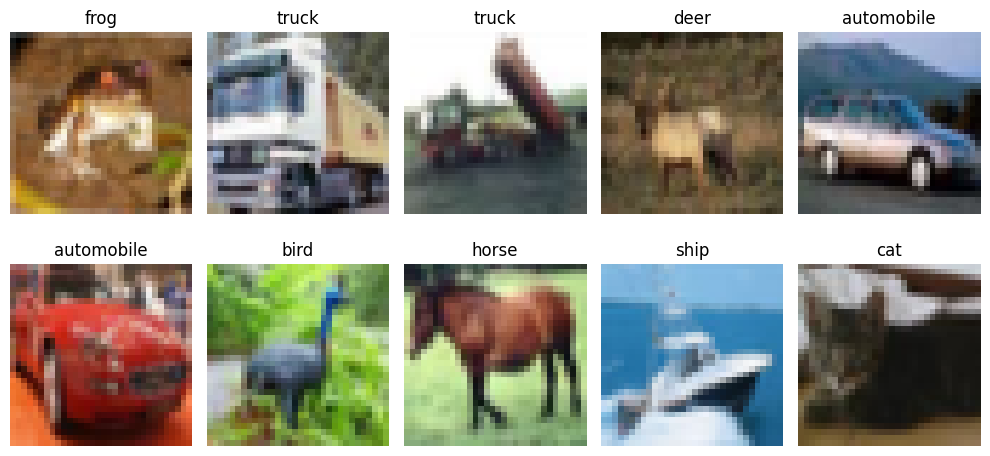

In [16]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Data Preprocessing
Normalizing pixel values to the range [0, 1] to ensure numerical stability and accelerate convergence during training.

In [17]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## Part 1: Artificial Neural Network (ANN)
Building a baseline ANN consisting of dense layers. The input images are flattened from 32x32x3 to a 1D vector of 3072 features.

In [18]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.2732 - loss: 1.9818 - val_accuracy: 0.3092 - val_loss: 1.8720
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3206 - loss: 1.8618 - val_accuracy: 0.3662 - val_loss: 1.7933
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3420 - loss: 1.8010 - val_accuracy: 0.3660 - val_loss: 1.7696
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3569 - loss: 1.7683 - val_accuracy: 0.3692 - val_loss: 1.7237
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3648 - loss: 1.7483 - val_accuracy: 0.3902 - val_loss: 1.7126
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3760 - loss: 1.7182 - val_accuracy: 0.4008 - val_loss: 1.6861
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3805 - loss: 1.7011 - val_accuracy: 0.4178 - val_loss: 1.6518
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3859 - loss: 1.6919 - 

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")

# Calculate Precision, Recall, F1
y_pred_ann = np.argmax(ann_model.predict(x_test_flat, verbose=0), axis=-1)
ann_precision = precision_score(y_test, y_pred_ann, average='macro')
ann_recall = recall_score(y_test, y_pred_ann, average='macro')
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')

print(f"ANN Precision: {ann_precision:.4f} | Recall: {ann_recall:.4f} | F1: {ann_f1:.4f}")

ANN Test Accuracy: 0.4325
ANN Precision: 0.4482 | Recall: 0.4325 | F1: 0.4275


## Part 2: Convolutional Neural Network (CNN)
Building a baseline CNN model. CNNs utilize convolutional layers to extract spatial hierarchies of features, which is highly effective for image data.

In [20]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Program Files\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 50ms/step - accuracy: 0.4718 - loss: 1.4826 - val_accuracy: 0.5038 - val_loss: 1.4329
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6121 - loss: 1.1075 - val_accuracy: 0.5982 - val_loss: 1.1140
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6718 - loss: 0.9394 - val_accuracy: 0.6086 - val_loss: 1.0982
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.7149 - loss: 0.8203 - val_accuracy: 0.5694 - val_loss: 1.3750
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.7413 - loss: 0.7365 - val_accuracy: 0.6506 - val_loss: 1.0593
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7680 - loss: 0.6556 - val_accuracy: 0.6966 - val_loss: 0.8954
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7926 - loss: 0.5889 - val_accuracy: 0.6988 - val_loss: 0.9248
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.8094 - loss: 0.5361 - 

In [21]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

y_pred_cnn = np.argmax(cnn_model.predict(x_test_norm, verbose=0), axis=-1)
cnn_precision = precision_score(y_test, y_pred_cnn, average='macro')
cnn_recall = recall_score(y_test, y_pred_cnn, average='macro')
cnn_f1 = f1_score(y_test, y_pred_cnn, average='macro')

print(f"CNN Precision: {cnn_precision:.4f} | Recall: {cnn_recall:.4f} | F1: {cnn_f1:.4f}")

CNN Test Accuracy: 0.6493
CNN Precision: 0.6761 | Recall: 0.6493 | F1: 0.6451


## Part 3: Advanced CNN Model
Implementing an advanced CNN architecture featuring:
1. **Data Augmentation**: To artificially expand the training dataset and reduce overfitting.
2. **Deeper Architecture**: Three convolutional blocks with increasing filter sizes (32, 64, 128).
3. **Regularization**: Batch Normalization, Dropout, and L2 Weight Regularization to improve model generalization.

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

adv_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    # Data Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

adv_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

adv_cnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           51

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [23]:
# Add Early Stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train the Advanced CNN model
# Using verbose=3 to avoid Jupyter notebook progress bar overload issues
adv_cnn_history = adv_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=3
)

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


In [24]:
adv_cnn_test_loss, adv_cnn_test_acc = adv_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Advanced CNN Test Accuracy: {adv_cnn_test_acc:.4f}")

y_pred_adv = np.argmax(adv_cnn_model.predict(x_test_norm, verbose=0), axis=-1)
adv_cnn_precision = precision_score(y_test, y_pred_adv, average='macro')
adv_cnn_recall = recall_score(y_test, y_pred_adv, average='macro')
adv_cnn_f1 = f1_score(y_test, y_pred_adv, average='macro')

print(f"Adv CNN Precision: {adv_cnn_precision:.4f} | Recall: {adv_cnn_recall:.4f} | F1: {adv_cnn_f1:.4f}")

Advanced CNN Test Accuracy: 0.7464
Adv CNN Precision: 0.7544 | Recall: 0.7464 | F1: 0.7423


## Unified Learning Curves (ANN vs CNN vs Advanced CNN)
Visualizing the validation accuracy and loss across all three models to compare their learning behavior and generalization capability.

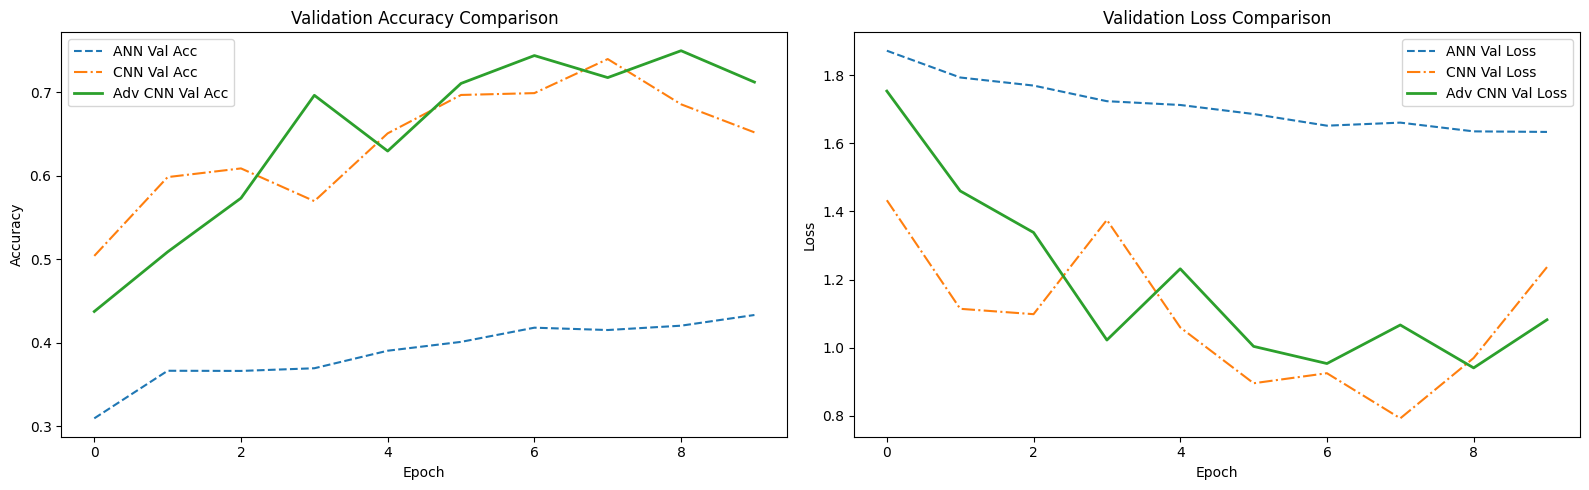

In [25]:
# Plot learning curves for all 3 models
plt.figure(figsize=(16, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc', linestyle='-.')
plt.plot(adv_cnn_history.history['val_accuracy'], label='Adv CNN Val Acc', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(ann_history.history['val_loss'], label='ANN Val Loss', linestyle='--')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss', linestyle='-.')
plt.plot(adv_cnn_history.history['val_loss'], label='Adv CNN Val Loss', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Final Comparison Table
Consolidating the evaluation metrics (Test Loss and Test Accuracy) for the ANN, baseline CNN, and the Advanced CNN into a summary dataframe.

In [26]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ANN", "Baseline CNN", "Advanced CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, adv_cnn_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, adv_cnn_test_loss],
    "Precision": [ann_precision, cnn_precision, adv_cnn_precision],
    "Recall": [ann_recall, cnn_recall, adv_cnn_recall],
    "F1-Score": [ann_f1, cnn_f1, adv_cnn_f1]
})

# Sort by Test Accuracy descending
comparison.sort_values(by="Test Accuracy", ascending=False, inplace=True)
comparison.reset_index(drop=True, inplace=True)
comparison

,Model,Test Accuracy,Test Loss,Precision,Recall,F1-Score
0,Advanced CNN,0.7464,0.974403,0.754396,0.7464,0.742258
1,Baseline CNN,0.6493,1.245494,0.676069,0.6493,0.645052
2,ANN,0.4325,1.623083,0.448171,0.4325,0.427500


## Conclusion

- **ANN (43.25% accuracy, F1: 0.4275)**: As expected, the fully-connected network performed the worst. By flattening 32×32×3 images into 3,072-dimensional vectors, it discards all spatial structure — pixels lose their neighbourhood context, making it nearly impossible for the model to learn visual patterns like edges, textures, and shapes reliably.

- **Baseline CNN (64.93% accuracy, F1: 0.6451)**: The standard CNN delivered a significant **+21.68 percentage point** improvement over the ANN. Convolutional layers preserve spatial locality and learn hierarchical features (edges → textures → object parts), giving the model a fundamentally stronger inductive bias for image data.

- **Advanced CNN (74.64% accuracy, F1: 0.7423)**: The advanced architecture achieved the highest performance, a **+9.71 percentage point** gain over the Baseline CNN and **+31.39 pp** over the ANN. This improvement is attributed to a combination of techniques:
  - **Data Augmentation** (random flips, rotations, zoom) artificially expanded the training distribution, reducing overfitting to specific image orientations.
  - **L2 Regularization** penalised large weight values, encouraging the model to learn smoother, more generalisable feature maps.
  - **Dropout** (at rates of 0.2–0.5) randomly deactivated neurons during training, preventing co-adaptation and acting as an ensemble of smaller networks.
  - **BatchNormalization** after every convolutional block stabilised training, accelerated convergence, and provided a mild regularisation effect.
  - **Early Stopping** halted training when validation loss stopped improving, selecting the best-performing checkpoint automatically.